# BEAD Random Forest — Multi-Stratified Ensemble

Extends the EPA-inspired stratified approach by exploring **multiple stratification variables** and combining them via a **stacking meta-learner**.

### Why doesn't a single RF already stratify?
A global RF treats each feature as a numeric split candidate across the entire dataset. It **cannot** learn fundamentally different feature-importance structures per subgroup. For example, `miles_per_location` might be the dominant cost driver for fiber but irrelevant for fixed wireless — a global model compromises between these patterns. By training separate models per stratum, each learns its own feature relationships.

### Stratification variables explored:
1. **Technology** — deployment method (fiber, wireless, HFC, etc.)
2. **Region** — Census region grouping of states (Northeast, South, Midwest, West)
3. **Technology × Region** — nested/hierarchical stratification

### Ensemble combination methods:
- **Routed**: use only the matching stratum model
- **Stacked**: train a Ridge meta-learner on all stratum models' predictions

Target: `log1p(funding_per_location)`

In [1]:
from google.cloud import bigquery
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import RidgeCV
from sklearn.model_selection import train_test_split, cross_val_predict, KFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

client = bigquery.Client(project='broadband-data')
print('Connected to BigQuery: broadband-data')

Connected to BigQuery: broadband-data


In [2]:
# Load all data sources
df_projects = client.query("""
SELECT project_id, state, bead_support, estimated_miles_aerial_fiber,
       estimated_miles_buried_fiber, estimated_jobs, project_type, priority_broadband_project
FROM `broadband-data.fp_approved.deployment_projects`
""").to_dataframe()

df_locations = client.query("""
SELECT project_id, COUNT(*) AS funded_locations,
       SAFE_CAST(APPROX_TOP_COUNT(CAST(technology AS STRING), 1)[OFFSET(0)].value AS FLOAT64) AS technology,
       AVG(CAST(low_latency AS INT64)) AS avg_latency
FROM `broadband-data.fp_approved.locations`
GROUP BY project_id
""").to_dataframe()

state_name_to_abbr = {
    'Alabama': 'AL', 'Alaska': 'AK', 'Arizona': 'AZ', 'Arkansas': 'AR', 'California': 'CA',
    'Colorado': 'CO', 'Connecticut': 'CT', 'Delaware': 'DE', 'Florida': 'FL', 'Georgia': 'GA',
    'Hawaii': 'HI', 'Idaho': 'ID', 'Illinois': 'IL', 'Indiana': 'IN', 'Iowa': 'IA',
    'Kansas': 'KS', 'Kentucky': 'KY', 'Louisiana': 'LA', 'Maine': 'ME', 'Maryland': 'MD',
    'Massachusetts': 'MA', 'Michigan': 'MI', 'Minnesota': 'MN', 'Mississippi': 'MS',
    'Missouri': 'MO', 'Montana': 'MT', 'Nebraska': 'NE', 'Nevada': 'NV', 'New_Hampshire': 'NH',
    'New_Jersey': 'NJ', 'New_Mexico': 'NM', 'New_York': 'NY', 'North_Carolina': 'NC',
    'North_Dakota': 'ND', 'Ohio': 'OH', 'Oklahoma': 'OK', 'Oregon': 'OR', 'Pennsylvania': 'PA',
    'Rhode_Island': 'RI', 'South_Carolina': 'SC', 'South_Dakota': 'SD', 'Tennessee': 'TN',
    'Texas': 'TX', 'Utah': 'UT', 'Vermont': 'VT', 'Virginia': 'VA', 'Washington': 'WA',
    'West_Virginia': 'WV', 'Wisconsin': 'WI', 'Wyoming': 'WY', 'District_of_Columbia': 'DC'
}
df_nbm = client.query("""
SELECT state, COUNT(DISTINCT frn) AS state_num_providers
FROM `broadband-data.fcc_nbm.nbm_hive` GROUP BY state
""").to_dataframe()
df_nbm['state'] = df_nbm['state'].map(state_name_to_abbr)
df_nbm = df_nbm.dropna(subset=['state'])

df_state_pop = client.query("""
SELECT stateabbr AS state, SUM(pop2020) AS state_population
FROM `broadband-data.fcc_block_level_pop.us2020` GROUP BY stateabbr
""").to_dataframe()

print(f'Projects: {df_projects.shape}, Locations: {df_locations.shape}')

Projects: (5251, 8), Locations: (5228, 4)


In [3]:
# Merge + feature engineering
df = df_projects.merge(df_locations, on='project_id', how='left')
df = df.merge(df_nbm, on='state', how='left')
df = df.merge(df_state_pop, on='state', how='left')

df['funded_locations'] = df['funded_locations'].fillna(0)
df['technology'] = df['technology'].fillna(0)
df['state_num_providers'] = df['state_num_providers'].fillna(0)
df['state_population'] = df['state_population'].fillna(0)

df['total_fiber_miles'] = df['estimated_miles_aerial_fiber'].fillna(0) + df['estimated_miles_buried_fiber'].fillna(0)
df['miles_per_location'] = df['total_fiber_miles'] / df['funded_locations'].replace(0, np.nan)
df['miles_per_location'] = df['miles_per_location'].fillna(0)
df['jobs_per_location'] = df['estimated_jobs'] / df['funded_locations'].replace(0, np.nan)
df['jobs_per_location'] = df['jobs_per_location'].fillna(0)

df['funding_per_location'] = df['bead_support'] / df['funded_locations'].replace(0, np.nan)
df = df.dropna(subset=['funding_per_location'])
low = df['funding_per_location'].quantile(0.025)
high = df['funding_per_location'].quantile(0.975)
df = df[(df['funding_per_location'] >= low) & (df['funding_per_location'] <= high)]

df['log_funding'] = np.log1p(df['funding_per_location'])
print(f'Samples after outlier removal: {df.shape[0]}')

Samples after outlier removal: 4962


## Create Stratification Variables

In [4]:
# 1. Technology groups (same as bead_rf_stratified)
tech_labels = {
    0: 'Unknown', 10: 'Copper', 40: 'HFC', 50: 'Fiber',
    60: 'Satellite', 61: 'Code 61', 70: 'FW', 71: 'Lic FW', 72: 'LBR FW'
}
MIN_STRATUM = 50
tech_counts = df['technology'].value_counts()
small_techs = tech_counts[tech_counts < MIN_STRATUM].index.tolist()
df['tech_group'] = df['technology'].apply(lambda x: -1 if x in small_techs else x)

# 2. Census region
region_map = {
    'CT': 'Northeast', 'ME': 'Northeast', 'MA': 'Northeast', 'NH': 'Northeast',
    'RI': 'Northeast', 'VT': 'Northeast', 'NJ': 'Northeast', 'NY': 'Northeast', 'PA': 'Northeast',
    'IL': 'Midwest', 'IN': 'Midwest', 'MI': 'Midwest', 'OH': 'Midwest', 'WI': 'Midwest',
    'IA': 'Midwest', 'KS': 'Midwest', 'MN': 'Midwest', 'MO': 'Midwest', 'NE': 'Midwest',
    'ND': 'Midwest', 'SD': 'Midwest',
    'DE': 'South', 'FL': 'South', 'GA': 'South', 'MD': 'South', 'NC': 'South',
    'SC': 'South', 'VA': 'South', 'DC': 'South', 'WV': 'South', 'AL': 'South',
    'KY': 'South', 'MS': 'South', 'TN': 'South', 'AR': 'South', 'LA': 'South',
    'OK': 'South', 'TX': 'South',
    'AZ': 'West', 'CO': 'West', 'ID': 'West', 'MT': 'West', 'NV': 'West',
    'NM': 'West', 'UT': 'West', 'WY': 'West', 'AK': 'West', 'CA': 'West',
    'HI': 'West', 'OR': 'West', 'WA': 'West',
}
df['region'] = df['state'].map(region_map).fillna('Other')

# 3. Technology × Region (nested)
df['tech_x_region'] = df['tech_group'].astype(int).astype(str) + '_' + df['region']

# Collapse small nested strata
txr_counts = df['tech_x_region'].value_counts()
small_txr = txr_counts[txr_counts < MIN_STRATUM].index.tolist()
df['tech_x_region_grouped'] = df['tech_x_region'].apply(lambda x: 'Small' if x in small_txr else x)

print('=== Stratification Variable Distributions ===')
print(f'\nTechnology groups ({df["tech_group"].nunique()}):')
for code, count in df['tech_group'].value_counts().sort_values(ascending=False).items():
    print(f'  {tech_labels.get(int(code), "Other")}: {count}')

print(f'\nRegions ({df["region"].nunique()}):')
for r, count in df['region'].value_counts().sort_values(ascending=False).items():
    print(f'  {r}: {count}')

print(f'\nTech × Region (after grouping, {df["tech_x_region_grouped"].nunique()} groups):')
for g, count in df['tech_x_region_grouped'].value_counts().sort_values(ascending=False).items():
    print(f'  {g}: {count}')

=== Stratification Variable Distributions ===

Technology groups (6):
  Fiber: 2430
  Code 61: 1831
  Lic FW: 461
  LBR FW: 145
  HFC: 62
  Other: 33

Regions (4):
  Midwest: 2228
  South: 1397
  West: 1086
  Northeast: 251

Tech × Region (after grouping, 13 groups):
  50_Midwest: 1149
  61_Midwest: 777
  50_South: 724
  61_South: 520
  61_West: 470
  50_West: 416
  71_Midwest: 234
  Small: 173
  50_Northeast: 141
  71_West: 113
  71_South: 112
  72_West: 69
  61_Northeast: 64


## Helper: Train Stratified Models + Evaluate

In [5]:
def train_stratified_ensemble(df, strat_col, feature_cols, target_col, n_trees=1500,
                              test_size=0.2, random_state=42, verbose=True):
    """
    Train one RF per stratum. Returns models, metrics, and train/test indices.
    Features used by each stratum model exclude any feature that equals the stratification variable.
    """
    X_all = df[feature_cols].fillna(0)
    y_all = df[target_col]
    strat_all = df[strat_col]
    
    # Global train/test split (consistent across all stratification schemes)
    idx_train, idx_test = train_test_split(df.index, test_size=test_size, random_state=random_state)
    
    X_train, X_test = X_all.loc[idx_train], X_all.loc[idx_test]
    y_train, y_test = y_all.loc[idx_train], y_all.loc[idx_test]
    strat_train, strat_test = strat_all.loc[idx_train], strat_all.loc[idx_test]
    
    models = {}
    metrics = {}
    
    groups = sorted(strat_train.unique())
    if verbose:
        print(f'Training {len(groups)} stratum models ({strat_col})...\n')
    
    for g in groups:
        mask_tr = strat_train == g
        X_tr_g = X_train[mask_tr]
        y_tr_g = y_train[mask_tr]
        
        rf = RandomForestRegressor(n_estimators=n_trees, min_samples_split=5,
                                  random_state=random_state, n_jobs=-1)
        rf.fit(X_tr_g, y_tr_g)
        models[g] = rf
        
        # Evaluate on within-stratum test samples
        mask_te = strat_test == g
        n_te = mask_te.sum()
        if n_te > 1:
            y_pred_g = rf.predict(X_test[mask_te])
            r2 = r2_score(y_test[mask_te], y_pred_g)
            rmse = np.sqrt(mean_squared_error(np.expm1(y_test[mask_te]), np.expm1(y_pred_g)))
        else:
            r2 = np.nan
            rmse = np.nan
        
        metrics[g] = {'n_train': mask_tr.sum(), 'n_test': n_te, 'r2': r2, 'rmse': rmse}
        if verbose:
            print(f'  {g}: train={mask_tr.sum()}, test={n_te}, R²={r2:.4f}, RMSE=${rmse:,.0f}' if n_te > 1
                  else f'  {g}: train={mask_tr.sum()}, test={n_te} (too few to evaluate)')
    
    # Routed predictions on global test set
    y_pred_routed = np.full(len(X_test), np.nan)
    for g, model in models.items():
        mask = strat_test == g
        if mask.sum() > 0:
            y_pred_routed[mask.values] = model.predict(X_test[mask])
    
    # Fallback for any unmatched (shouldn't happen but safety)
    nan_mask = np.isnan(y_pred_routed)
    if nan_mask.any():
        fallback_rf = RandomForestRegressor(n_estimators=n_trees, min_samples_split=5,
                                           random_state=random_state, n_jobs=-1)
        fallback_rf.fit(X_train, y_train)
        y_pred_routed[nan_mask] = fallback_rf.predict(X_test.values[nan_mask])
    
    r2_routed = r2_score(y_test, y_pred_routed)
    rmse_routed = np.sqrt(mean_squared_error(np.expm1(y_test), np.expm1(y_pred_routed)))
    mae_routed = mean_absolute_error(np.expm1(y_test), np.expm1(y_pred_routed))
    
    if verbose:
        print(f'\n  Routed Ensemble: R²={r2_routed:.4f}, RMSE=${rmse_routed:,.0f}, MAE=${mae_routed:,.0f}')
    
    return {
        'models': models, 'metrics': metrics,
        'idx_train': idx_train, 'idx_test': idx_test,
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train, 'y_test': y_test,
        'strat_train': strat_train, 'strat_test': strat_test,
        'y_pred_routed': y_pred_routed,
        'routed_r2': r2_routed, 'routed_rmse': rmse_routed, 'routed_mae': mae_routed,
    }

print('Helper function defined.')

Helper function defined.


## 1. Global Baseline (no stratification)

In [6]:
feature_cols = [
    'miles_per_location',
    'technology',
    'jobs_per_location',
    'state_population',
    'total_fiber_miles',
    'state_num_providers',
]

# Use same train/test split for all experiments
idx_train, idx_test = train_test_split(df.index, test_size=0.2, random_state=42)

X_train_g = df.loc[idx_train, feature_cols].fillna(0)
X_test_g = df.loc[idx_test, feature_cols].fillna(0)
y_train_g = df.loc[idx_train, 'log_funding']
y_test_g = df.loc[idx_test, 'log_funding']

rf_global = RandomForestRegressor(n_estimators=1500, min_samples_split=5, random_state=42, n_jobs=-1)
rf_global.fit(X_train_g, y_train_g)
y_pred_global = rf_global.predict(X_test_g)

r2_global = r2_score(y_test_g, y_pred_global)
rmse_global = np.sqrt(mean_squared_error(np.expm1(y_test_g), np.expm1(y_pred_global)))
mae_global = mean_absolute_error(np.expm1(y_test_g), np.expm1(y_pred_global))

print('=== Global RF Baseline (6 features, 1500 trees) ===')
print(f'R²={r2_global:.4f}  RMSE=${rmse_global:,.0f}  MAE=${mae_global:,.0f}')

=== Global RF Baseline (6 features, 1500 trees) ===
R²=0.7425  RMSE=$2,488  MAE=$1,419


## 2. Stratify by Technology

In [7]:
# When stratifying by technology, remove it from features
feat_no_tech = [f for f in feature_cols if f != 'technology']
res_tech = train_stratified_ensemble(df, 'tech_group', feat_no_tech, 'log_funding')

Training 6 stratum models (tech_group)...



  -1.0: train=26, test=7, R²=0.4525, RMSE=$1,806


  40.0: train=50, test=12, R²=0.6389, RMSE=$2,559


  50.0: train=1945, test=485, R²=0.4171, RMSE=$3,217


  61.0: train=1467, test=364, R²=0.6977, RMSE=$398


  71.0: train=371, test=90, R²=0.3563, RMSE=$2,267


  72.0: train=110, test=35, R²=0.1989, RMSE=$3,253



  Routed Ensemble: R²=0.7430, RMSE=$2,460, MAE=$1,413


## 3. Stratify by Region

In [8]:
# When stratifying by region, keep technology as a feature but drop state-level features
# (state_population and state_num_providers are partially captured by region)
feat_no_state = [f for f in feature_cols if f not in ('state_population', 'state_num_providers')]
res_region = train_stratified_ensemble(df, 'region', feat_no_state, 'log_funding')

Training 4 stratum models (region)...



  Midwest: train=1759, test=469, R²=0.6472, RMSE=$2,199


  Northeast: train=199, test=52, R²=0.5425, RMSE=$3,891


  South: train=1134, test=263, R²=0.6261, RMSE=$2,838


  West: train=877, test=209, R²=0.6940, RMSE=$2,923



  Routed Ensemble: R²=0.6561, RMSE=$2,647, MAE=$1,590


## 4. Stratify by Technology × Region (nested)

In [9]:
# Nested: remove both technology and state-level features
feat_nested = [f for f in feature_cols if f not in ('technology', 'state_population', 'state_num_providers')]
res_nested = train_stratified_ensemble(df, 'tech_x_region_grouped', feat_nested, 'log_funding')

Training 13 stratum models (tech_x_region_grouped)...



  50_Midwest: train=913, test=236, R²=0.4946, RMSE=$2,840


  50_Northeast: train=110, test=31, R²=0.1829, RMSE=$4,277


  50_South: train=592, test=132, R²=-0.0315, RMSE=$3,921


  50_West: train=330, test=86, R²=0.2209, RMSE=$3,831


...

  71_South: train=87, test=25, R²=-1.2300, RMSE=$1,310


  71_West: train=95, test=18, R²=0.3466, RMSE=$3,649


  72_West: train=51, test=18, R²=0.3076, RMSE=$2,896


  Small: train=137, test=36, R²=0.4096, RMSE=$2,964



  Routed Ensemble: R²=0.6582, RMSE=$2,636, MAE=$1,594


## 5. Stacking Meta-Learner
Train a Ridge regression that takes predictions from **all** stratum models (tech, region, nested) as inputs and learns the optimal combination weights. Uses out-of-fold predictions to avoid data leakage.

In [10]:
def generate_oof_predictions(df, strat_col, feature_cols, target_col, n_trees=1500,
                             n_folds=5, random_state=42):
    """
    Generate out-of-fold predictions for stacking.
    For each fold: train stratum models on fold's training data, predict on fold's held-out data.
    Returns array of routed predictions aligned with df index.
    """
    X = df[feature_cols].fillna(0)
    y = df[target_col]
    strat = df[strat_col]
    
    oof_preds = np.full(len(df), np.nan)
    kf = KFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    for fold, (tr_idx, val_idx) in enumerate(kf.split(X)):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr = y.iloc[tr_idx]
        strat_tr, strat_val = strat.iloc[tr_idx], strat.iloc[val_idx]
        
        # Train stratum models on this fold's training data
        for g in strat_tr.unique():
            mask_tr = strat_tr == g
            mask_val = strat_val == g
            if mask_tr.sum() < 5:
                continue
            
            rf = RandomForestRegressor(n_estimators=n_trees, min_samples_split=5,
                                      random_state=random_state, n_jobs=-1)
            rf.fit(X_tr[mask_tr], y_tr[mask_tr])
            
            if mask_val.sum() > 0:
                oof_preds[val_idx[mask_val.values]] = rf.predict(X_val[mask_val])
        
        # Fallback for unmatched validation samples
        still_nan = np.isnan(oof_preds[val_idx])
        if still_nan.any():
            rf_fb = RandomForestRegressor(n_estimators=n_trees, min_samples_split=5,
                                         random_state=random_state, n_jobs=-1)
            rf_fb.fit(X_tr, y_tr)
            nan_positions = val_idx[still_nan]
            oof_preds[nan_positions] = rf_fb.predict(X.iloc[nan_positions])
    
    return oof_preds

print('Generating out-of-fold predictions for 3 stratification schemes...')
oof_tech = generate_oof_predictions(df, 'tech_group', feat_no_tech, 'log_funding')
print('  Technology OOF done.')
oof_region = generate_oof_predictions(df, 'region', feat_no_state, 'log_funding')
print('  Region OOF done.')
oof_nested = generate_oof_predictions(df, 'tech_x_region_grouped', feat_nested, 'log_funding')
print('  Tech×Region OOF done.')

# Also need global model OOF
kf = KFold(n_splits=5, shuffle=True, random_state=42)
oof_global = cross_val_predict(RandomForestRegressor(n_estimators=1500, min_samples_split=5,
                                                     random_state=42, n_jobs=-1),
                               df[feature_cols].fillna(0), df['log_funding'], cv=kf)
print('  Global OOF done.')

print(f'\nOOF prediction coverage: tech={np.isfinite(oof_tech).mean():.1%}, '
      f'region={np.isfinite(oof_region).mean():.1%}, '
      f'nested={np.isfinite(oof_nested).mean():.1%}')

Generating out-of-fold predictions for 3 stratification schemes...


  Technology OOF done.


  Region OOF done.


  Tech×Region OOF done.


  Global OOF done.

OOF prediction coverage: tech=100.0%, region=100.0%, nested=100.0%


In [11]:
# Stack: train Ridge meta-learner on OOF predictions
stack_features = np.column_stack([oof_global, oof_tech, oof_region, oof_nested])
stack_labels = ['Global', 'Tech-Stratified', 'Region-Stratified', 'Tech×Region']

# Use train/test split from earlier
stack_train = stack_features[df.index.isin(idx_train)]
stack_test = stack_features[df.index.isin(idx_test)]
y_stack_train = df.loc[idx_train, 'log_funding']
y_stack_test = df.loc[idx_test, 'log_funding']

# Need test-set predictions from each full model (not OOF)
X_test_stack = df.loc[idx_test, feature_cols].fillna(0)
pred_global_test = rf_global.predict(X_test_stack)
pred_tech_test = res_tech['y_pred_routed']
pred_region_test = res_region['y_pred_routed']
pred_nested_test = res_nested['y_pred_routed']

stack_test_preds = np.column_stack([pred_global_test, pred_tech_test, pred_region_test, pred_nested_test])

meta = RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0])
meta.fit(stack_train, df.loc[idx_train, 'log_funding'])

y_pred_stacked = meta.predict(stack_test_preds)

r2_stacked = r2_score(y_stack_test, y_pred_stacked)
rmse_stacked = np.sqrt(mean_squared_error(np.expm1(y_stack_test), np.expm1(y_pred_stacked)))
mae_stacked = mean_absolute_error(np.expm1(y_stack_test), np.expm1(y_pred_stacked))

print('=== Stacking Meta-Learner (Ridge) ===')
print(f'R²={r2_stacked:.4f}  RMSE=${rmse_stacked:,.0f}  MAE=${mae_stacked:,.0f}')
print(f'Best alpha: {meta.alpha_}')
print(f'\nMeta-learner weights:')
for label, w in zip(stack_labels, meta.coef_):
    print(f'  {label}: {w:.4f}')
print(f'  Intercept: {meta.intercept_:.4f}')

=== Stacking Meta-Learner (Ridge) ===
R²=-0.0147  RMSE=$4,123  MAE=$2,894
Best alpha: 100.0

Meta-learner weights:
  Global: 0.0358
  Tech-Stratified: 0.0276
  Region-Stratified: -0.0443
  Tech×Region: -0.0358
  Intercept: 7.9973


## Results: All Methods Compared

In [12]:
# Comprehensive comparison table
all_results = pd.DataFrame([
    {'Method': 'Global RF (baseline)', 'R² (log)': r2_global, 
     'RMSE ($)': rmse_global, 'MAE ($)': mae_global},
    {'Method': 'Tech-Stratified (routed)', 'R² (log)': res_tech['routed_r2'],
     'RMSE ($)': res_tech['routed_rmse'], 'MAE ($)': res_tech['routed_mae']},
    {'Method': 'Region-Stratified (routed)', 'R² (log)': res_region['routed_r2'],
     'RMSE ($)': res_region['routed_rmse'], 'MAE ($)': res_region['routed_mae']},
    {'Method': 'Tech×Region (routed)', 'R² (log)': res_nested['routed_r2'],
     'RMSE ($)': res_nested['routed_rmse'], 'MAE ($)': res_nested['routed_mae']},
    {'Method': 'Stacked Ensemble', 'R² (log)': r2_stacked,
     'RMSE ($)': rmse_stacked, 'MAE ($)': mae_stacked},
]).set_index('Method')

# Add delta columns
all_results['R² vs Global'] = all_results['R² (log)'] - r2_global
all_results['RMSE vs Global'] = all_results['RMSE ($)'] - rmse_global

print('=== FULL MODEL COMPARISON ===')
print(all_results.to_string(float_format=lambda x: f'{x:.4f}' if abs(x) < 100 else f'${x:,.0f}'))

print(f'\nBest R²: {all_results["R² (log)"].idxmax()} ({all_results["R² (log)"].max():.4f})')
print(f'Best RMSE: {all_results["RMSE ($)"].idxmin()} (${all_results["RMSE ($)"].min():,.0f})')

=== FULL MODEL COMPARISON ===
                            R² (log)  RMSE ($)  MAE ($)  R² vs Global  RMSE vs Global
Method                                                                               
Global RF (baseline)          0.7425    $2,488   $1,419        0.0000          0.0000
Tech-Stratified (routed)      0.7430    $2,460   $1,413        0.0005        -27.4769
Region-Stratified (routed)    0.6561    $2,647   $1,590       -0.0864            $160
Tech×Region (routed)          0.6582    $2,636   $1,594       -0.0843            $149
Stacked Ensemble             -0.0147    $4,123   $2,894       -0.7572          $1,635

Best R²: Tech-Stratified (routed) (0.7430)
Best RMSE: Tech-Stratified (routed) ($2,460)


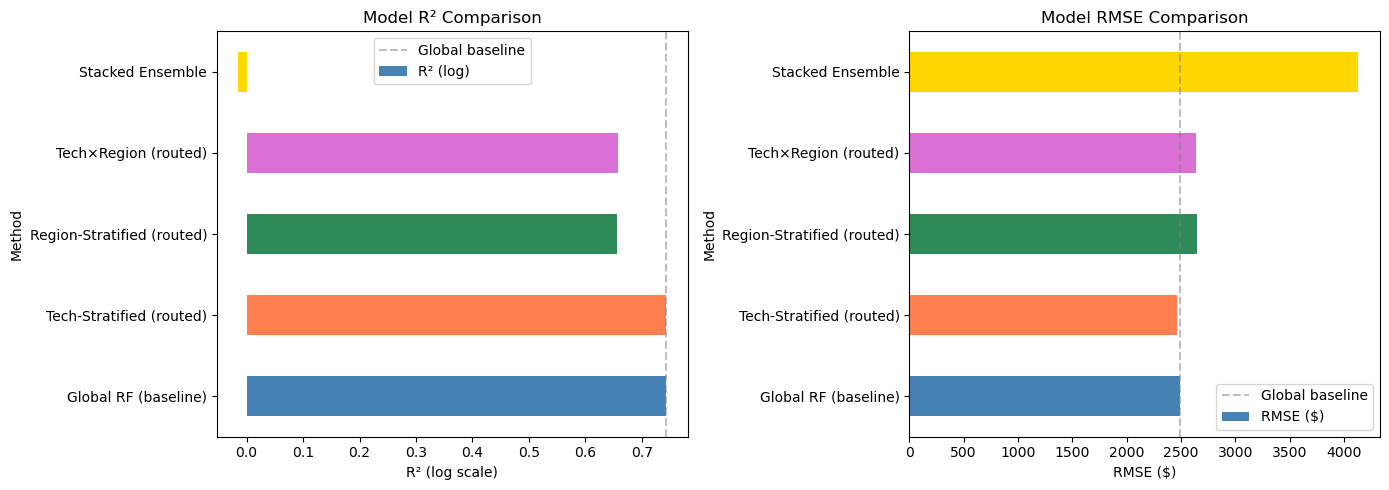

In [13]:
# Bar chart comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ['steelblue', 'coral', 'seagreen', 'orchid', 'gold']

# R² comparison
all_results['R² (log)'].plot.barh(ax=axes[0], color=colors)
axes[0].set_xlabel('R² (log scale)')
axes[0].set_title('Model R² Comparison')
axes[0].axvline(x=r2_global, color='gray', linestyle='--', alpha=0.5, label='Global baseline')
axes[0].legend()

# RMSE comparison
all_results['RMSE ($)'].plot.barh(ax=axes[1], color=colors)
axes[1].set_xlabel('RMSE ($)')
axes[1].set_title('Model RMSE Comparison')
axes[1].axvline(x=rmse_global, color='gray', linestyle='--', alpha=0.5, label='Global baseline')
axes[1].legend()

plt.tight_layout()
plt.show()

## Predicted vs Actual: All Methods

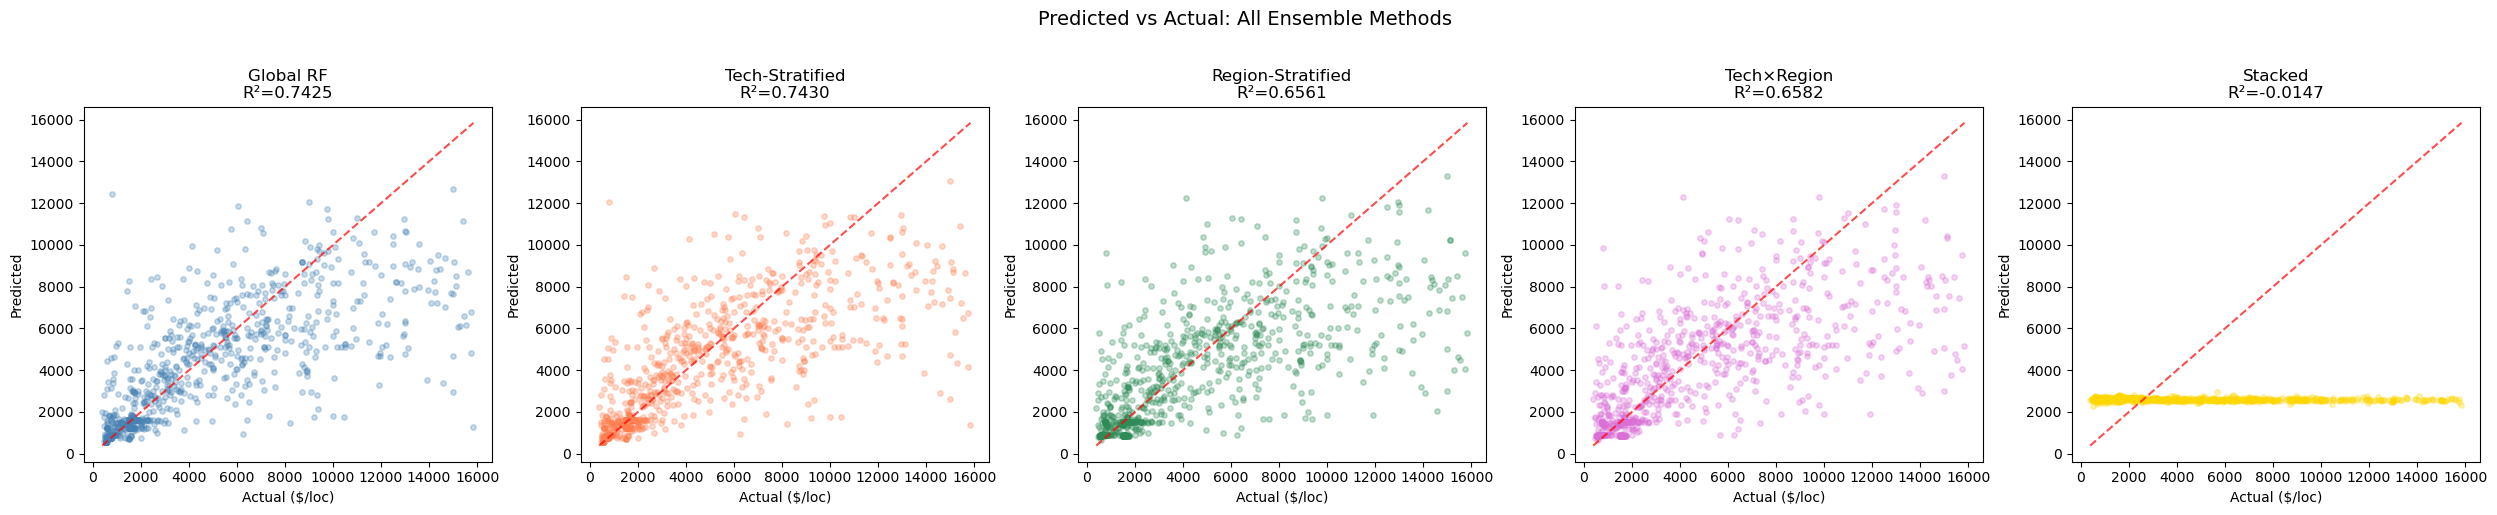

In [14]:
fig, axes = plt.subplots(1, 5, figsize=(25, 5))

methods = ['Global RF', 'Tech-Stratified', 'Region-Stratified', 'Tech×Region', 'Stacked']
preds_list = [y_pred_global, res_tech['y_pred_routed'], res_region['y_pred_routed'],
              res_nested['y_pred_routed'], y_pred_stacked]

for ax, method, y_p, color in zip(axes, methods, preds_list, colors):
    actual = np.expm1(y_test_g)
    predicted = np.expm1(y_p)
    r2 = r2_score(y_test_g, y_p)
    
    ax.scatter(actual, predicted, alpha=0.3, s=15, color=color)
    lims = [min(actual.min(), predicted.min()), max(actual.max(), predicted.max())]
    ax.plot(lims, lims, 'r--', alpha=0.7)
    ax.set_xlabel('Actual ($/loc)')
    ax.set_ylabel('Predicted')
    ax.set_title(f'{method}\nR²={r2:.4f}')

plt.suptitle('Predicted vs Actual: All Ensemble Methods', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Feature Importance Across Stratification Schemes

=== Feature Importance by Technology Stratum ===


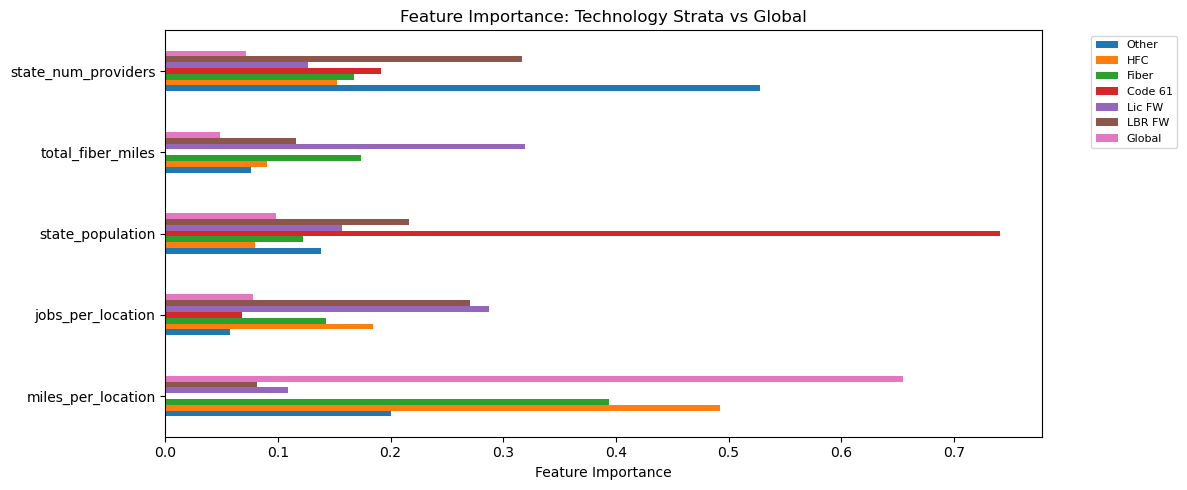


=== Feature Importance by Region Stratum ===


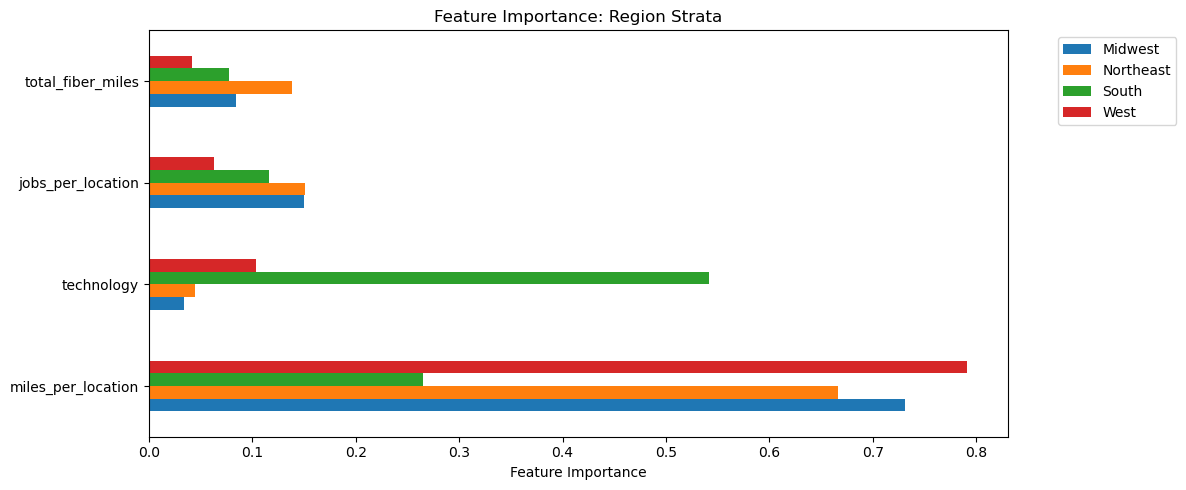


Key insight: if importance rankings differ substantially across strata,
stratification is capturing real structural differences in cost drivers.


In [15]:
# Compare how feature importance shifts across technology strata
print('=== Feature Importance by Technology Stratum ===')
tech_imp = pd.DataFrame({
    tech_labels.get(int(t), 'Other' if t == -1 else str(t)): 
    pd.Series(m.feature_importances_, index=feat_no_tech)
    for t, m in res_tech['models'].items()
})
tech_imp['Global'] = pd.Series(rf_global.feature_importances_, index=feature_cols).reindex(feat_no_tech)

fig, ax = plt.subplots(figsize=(12, 5))
tech_imp.plot.barh(ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance: Technology Strata vs Global')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

# Compare across region strata
print('\n=== Feature Importance by Region Stratum ===')
region_imp = pd.DataFrame({
    r: pd.Series(m.feature_importances_, index=feat_no_state)
    for r, m in res_region['models'].items()
})

fig, ax = plt.subplots(figsize=(12, 5))
region_imp.plot.barh(ax=ax)
ax.set_xlabel('Feature Importance')
ax.set_title('Feature Importance: Region Strata')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('\nKey insight: if importance rankings differ substantially across strata,')
print('stratification is capturing real structural differences in cost drivers.')

## SHAP: Technology Strata vs Global

Computing SHAP values per technology stratum...

--- Other (n=7) ---


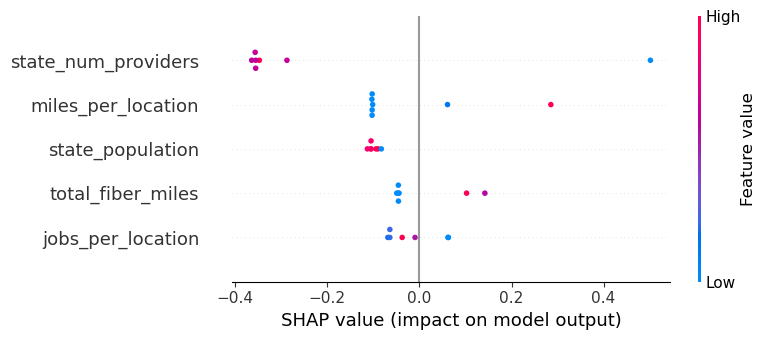


--- HFC (n=12) ---


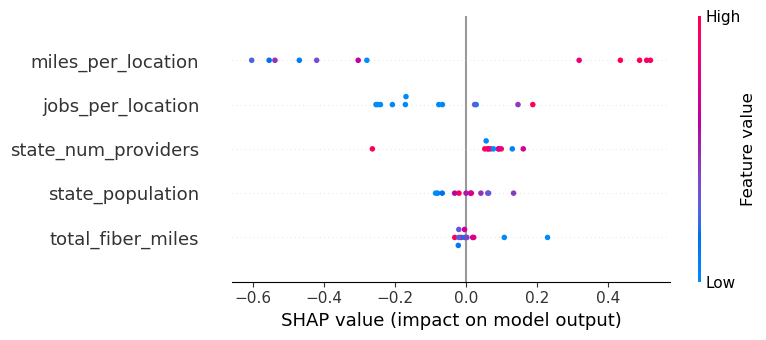


--- Fiber (n=485) ---


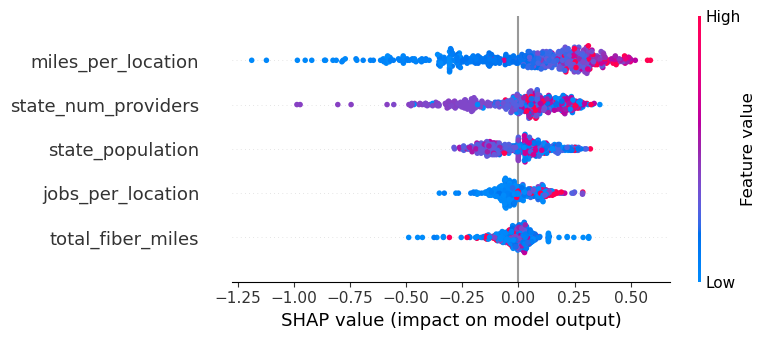


--- Code 61 (n=364) ---


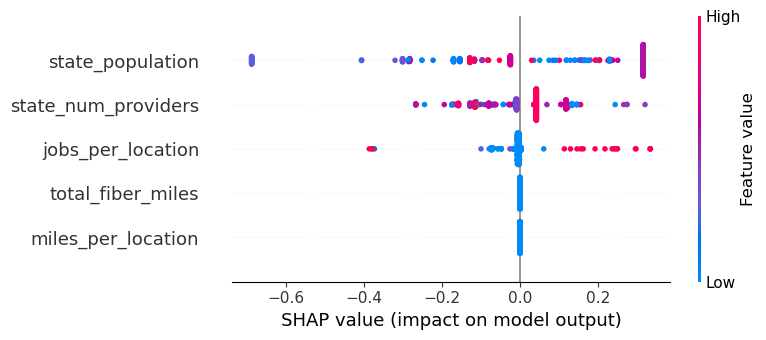


--- Lic FW (n=90) ---


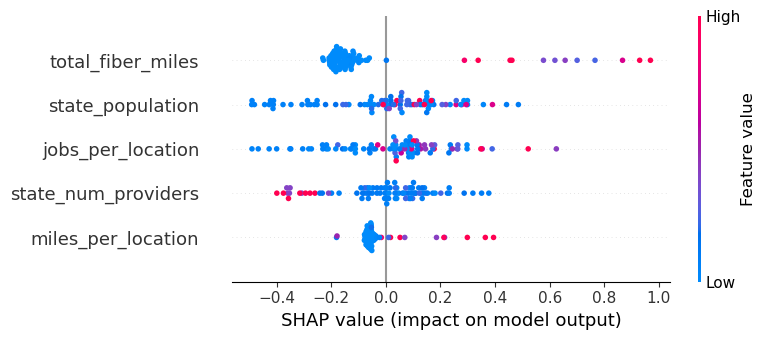


--- LBR FW (n=35) ---


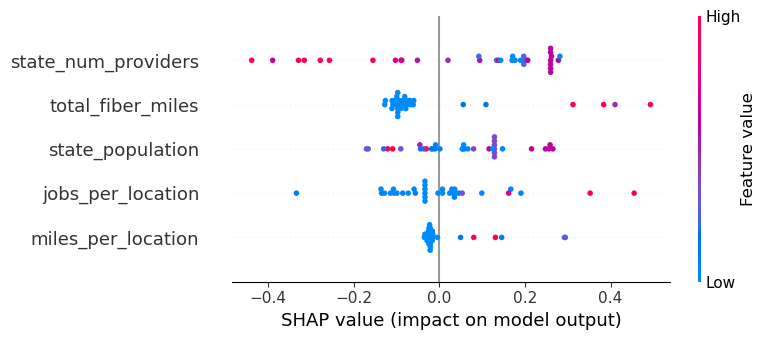

In [16]:
try:
    import shap
except ImportError:
    import subprocess
    subprocess.check_call(['pip', 'install', 'shap'])
    import shap

# SHAP for each technology stratum
print('Computing SHAP values per technology stratum...')
shap_by_tech = {}
for tech in sorted(res_tech['models'].keys()):
    model = res_tech['models'][tech]
    mask = res_tech['strat_test'] == tech
    X_te = res_tech['X_test'][mask]
    if len(X_te) < 5:
        continue
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_te)
    shap_by_tech[tech] = (sv, X_te)
    
    label = tech_labels.get(int(tech), 'Other' if tech == -1 else str(tech))
    print(f'\n--- {label} (n={len(X_te)}) ---')
    shap.summary_plot(sv, X_te, feature_names=feat_no_tech, show=True)

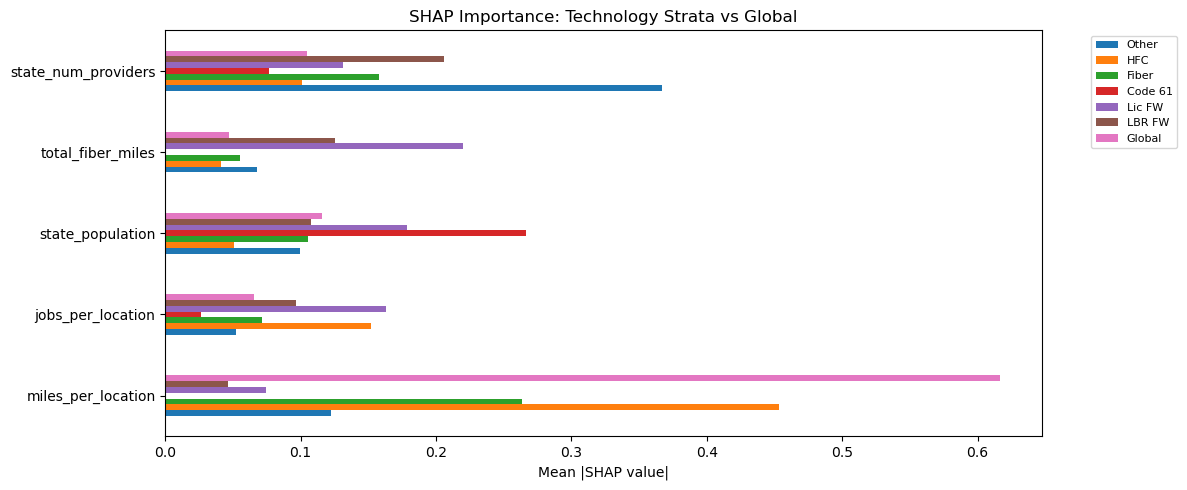

In [17]:
# SHAP importance comparison: mean |SHAP| across tech strata
shap_comp = pd.DataFrame({
    tech_labels.get(int(t), 'Other' if t == -1 else str(t)):
    pd.Series(np.abs(sv).mean(axis=0), index=feat_no_tech)
    for t, (sv, _) in shap_by_tech.items()
})

# Global SHAP
global_exp = shap.TreeExplainer(rf_global)
global_sv = global_exp.shap_values(X_test_g)
shap_comp['Global'] = pd.Series(np.abs(global_sv).mean(axis=0), index=feature_cols).reindex(feat_no_tech)

fig, ax = plt.subplots(figsize=(12, 5))
shap_comp.plot.barh(ax=ax)
ax.set_xlabel('Mean |SHAP value|')
ax.set_title('SHAP Importance: Technology Strata vs Global')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Final Assessment

In [18]:
print('=' * 70)
print('MULTI-STRATIFIED ENSEMBLE — FINAL ASSESSMENT')
print('=' * 70)

print(f'\n{"Method":<30} {"R²":>8} {"vs Global":>10} {"RMSE ($)":>10}')
print('-' * 60)

for method, row in all_results.iterrows():
    delta = row['R² (log)'] - r2_global
    marker = ' ***' if method == all_results['R² (log)'].idxmax() else ''
    print(f'{method:<30} {row["R² (log)"]:>8.4f} {delta:>+10.4f} {row["RMSE ($)"]:>10,.0f}{marker}')

print(f'\n*** = Best model')

# Interpretation
best_method = all_results['R² (log)'].idxmax()
best_r2 = all_results['R² (log)'].max()
improvement = best_r2 - r2_global

print(f'\n--- Interpretation ---')
if improvement > 0.05:
    print(f'Stratification provides substantial improvement (+{improvement:.4f} R²).')
    print(f'Best method: {best_method}')
    print(f'\nThis confirms that different deployment contexts (technology, region) have')
    print(f'distinct cost structures that a single global model cannot fully capture.')
elif improvement > 0.01:
    print(f'Stratification provides modest improvement (+{improvement:.4f} R²).')
    print(f'Best method: {best_method}')
else:
    print(f'Stratification provides minimal or no improvement ({improvement:+.4f} R²).')
    print(f'The global model already captures subgroup differences adequately.')

print(f'\n--- Stacking Meta-Learner Weights ---')
print(f'These show which stratification schemes the meta-learner relies on most:')
for label, w in sorted(zip(stack_labels, meta.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f'  {label}: {w:+.4f}')

MULTI-STRATIFIED ENSEMBLE — FINAL ASSESSMENT

Method                               R²  vs Global   RMSE ($)
------------------------------------------------------------
Global RF (baseline)             0.7425    +0.0000      2,488
Tech-Stratified (routed)         0.7430    +0.0005      2,460 ***
Region-Stratified (routed)       0.6561    -0.0864      2,647
Tech×Region (routed)             0.6582    -0.0843      2,636
Stacked Ensemble                -0.0147    -0.7572      4,123

*** = Best model

--- Interpretation ---
Stratification provides minimal or no improvement (+0.0005 R²).
The global model already captures subgroup differences adequately.

--- Stacking Meta-Learner Weights ---
These show which stratification schemes the meta-learner relies on most:
  Region-Stratified: -0.0443
  Tech×Region: -0.0358
  Global: +0.0358
  Tech-Stratified: +0.0276
